# Numpy and Scipy study

In [7]:
import numpy as np
import scipy as sp
import sklearn as sk
import matplotlib.pyplot as plt
import IPython
import librosa
import pywt
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from dataprocess.cwt.scalogram import plot_data
from dataprocess.cwt.cwt2 import rd_file, getDefaultScales, cwt2, cwt3
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

In [8]:
SOUND_FOLDER = '../data/sound/grasshopper-sound-4/'

In [9]:
data = [[1, -2], [-2, 3]]
a = np.abs(data)
print(f'abc of data is: {a}')

abc of data is: [[1 2]
 [2 3]]


## Normalize

In [11]:
d2 = np.arange(1, 10, 1)
print(d2)
print(f'd2 max: {d2.max()}, min: {d2.min()}, mean: {d2.mean()}')
d3 = d2 * 2
print(d3)
print(f'd3 max: {d3.max()}, min: {d3.min()}, mean: {d3.mean()}')
d4 = d2 * 0.5
print(d4)
print(f'd4 max: {d4.max()}, min: {d4.min()}, mean: {d4.mean()}')

d2_n = sk.preprocessing.minmax_scale(d2 - d2.mean(), feature_range=(0,1))
print(d2_n)

d3_n = sk.preprocessing.minmax_scale(d3 - d3.mean(), feature_range=(0,1))
print(d3_n)

d4_n = sk.preprocessing.minmax_scale(d4 - d4.mean(), feature_range=(0,1))
print(d4_n)

[1 2 3 4 5 6 7 8 9]
d2 max: 9, min: 1, mean: 5.0
[ 2  4  6  8 10 12 14 16 18]
d3 max: 18, min: 2, mean: 10.0
[0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5]
d4 max: 4.5, min: 0.5, mean: 2.5
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]


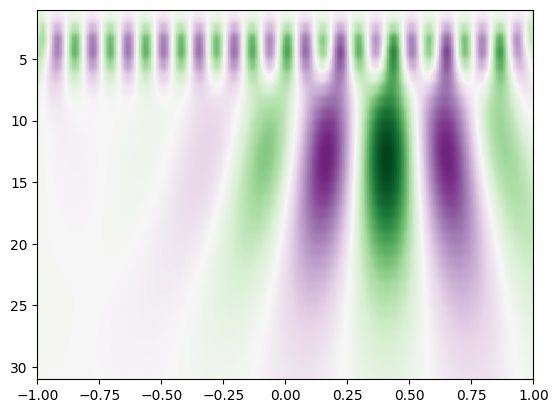

In [5]:
t = np.linspace(-1, 1, 200, endpoint=False)
sig  = np.cos(2 * np.pi * 7 * t) + sp.signal.gausspulse(t - 0.4, fc=2)
widths = np.arange(1, 31)
cwtmatr = sp.signal.cwt(sig, sp.signal.ricker, widths)
plt.imshow(cwtmatr, extent=[-1, 1, 31, 1], cmap='PRGn', aspect='auto',
           vmax=abs(cwtmatr).max(), vmin=-abs(cwtmatr).max())
plt.show()

In [3]:
d1, sr1, dura1 = rd_file(f'{SOUND_FOLDER}gh-4_mono_22050_denoised_filter.wav')
print(f'data size: {len(d1)}')
print(f'sample rate: {sr1}')
print(f'duration: {dura1}')

IPython.display.Audio(data=d1, rate=sr1)

data size: 228217
sample rate: 22050
duration: 10.349977324263039


/home/zhangjw/.cache/pypoetry/virtualenvs/pestdataprocess-pxU8UH9y-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  return f(*args, **kwargs)


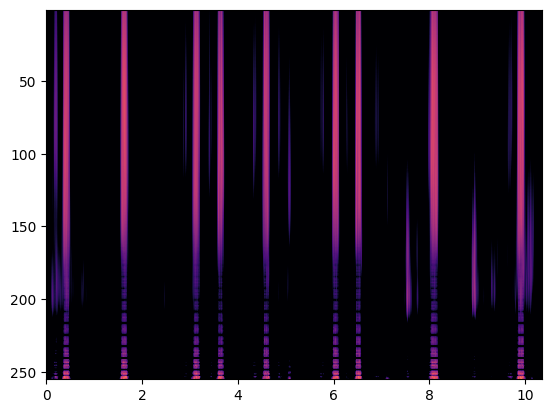

In [4]:
# widths = np.arange(1, 256)
# widths = getDefaultScales(len(d1), 1/12, sr1, 40)
#cwtmatr = sp.signal.cwt(d1, sp.signal.morlet, widths)
cwtmatr, _ = cwt3(d1, 10, sr1, 40.0)
plt.imshow(librosa.amplitude_to_db(cwtmatr), extent=[0.0, dura1, 
    cwtmatr.shape[0], 1], cmap='magma', aspect='auto', vmax=0, vmin=-60)
plt.show()


In [4]:
a = np.arange(1, 10, 2)
print(f'a:{a}')
mean = a.mean()
print(f'mean: {mean}')

a1 = a - mean
print(f'a1: {a1}')

from sklearn.preprocessing import minmax_scale

a2 = minmax_scale(a1, feature_range=(-1,1))
print(f'a2:{a2}')

a:[1 3 5 7 9]
mean: 5.0
a1: [-4. -2.  0.  2.  4.]
a2:[-1.  -0.5  0.   0.5  1. ]
